# Introduction
This colab worksheet provides a starting point for Task 2 (the computer vision task).

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3060 Laptop GPU


# Data Loading

In [34]:
# Download the data stored in a zipped numpy array from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.

import numpy as np

data = np.load('face_alignment_training_images.npz')
train_images = data['images']
train_points = data['points']

test_data = np.load('face_alignment_test_images.npz')
test_images = test_data['images']

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [35]:
import hashlib

def confirm_checksum(filename, expected_checksum, chunk_size=8192):
    """
    Compute the SHA-1 checksum of a file and compare it against the expected value.
    Raises an AssertionError if the checksums do not match.

    Args:
        filename (str): Path to the file to verify.
        expected_checksum (str): The expected SHA-1 checksum as a hex string.
        chunk_size (int): Number of bytes to read at a time (default: 8 KB).
    """
    sha1 = hashlib.sha1()
    with open(filename, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha1.update(chunk)
    computed_checksum = sha1.hexdigest()
    print(f"{filename} SHA-1: {computed_checksum}")
    assert computed_checksum == expected_checksum, (
        f"Checksum mismatch for {filename}! "
        "Please re-download the data."
    )

# Example usage:
confirm_checksum(
    'face_alignment_training_images.npz',
    'affc56216e34c827f10681a14c602981c06ddeb3'
)
confirm_checksum(
    'face_alignment_test_images.npz',
    'e480535442512b8175ae110d2d3e507378cabbdb'
)


face_alignment_training_images.npz SHA-1: affc56216e34c827f10681a14c602981c06ddeb3
face_alignment_test_images.npz SHA-1: e480535442512b8175ae110d2d3e507378cabbdb


# Load the data

In [36]:
import numpy as np


# Load the data using np.load
data = np.load('face_alignment_training_images.npz', allow_pickle=True)

# Extract the images
images = data['images']
# and the data points
pts = data['points']

print(images.shape, pts.shape)

test_data = np.load('face_alignment_test_images.npz', allow_pickle=True)
test_images = test_data['images']
print(test_images.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

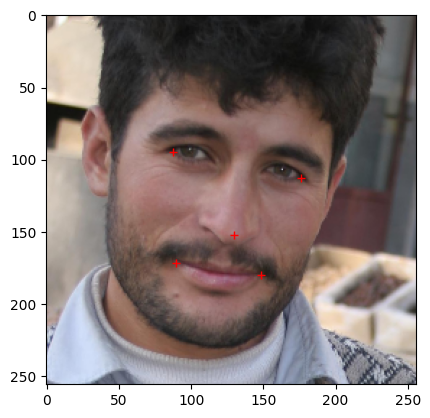

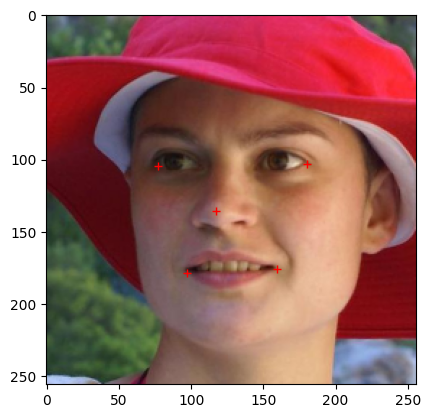

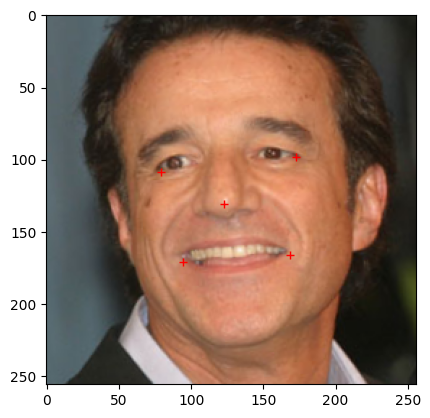

In [37]:

def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+r')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images.shape[0])
  visualise_pts(images[idx, ...], pts[idx, ...])

# Image preprocessing

In [40]:
# data_utils.py
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

def preprocess_data(images, landmarks=None, target_size=(224, 224)):
    """
    Resize & normalize images; scale landmarks accordingly.
    Pure NumPy/OpenCV implementation.
    """
    imgs, pts = [], []
    for i, img in enumerate(images):
        h0, w0 = img.shape[:2]
        img_resized = cv2.resize(img, target_size)
        img_norm = img_resized.astype(np.float32) / 255.0
        imgs.append(img_norm)

        if landmarks is not None:
            lm = landmarks[i].copy()
            sx, sy = target_size[0]/w0, target_size[1]/h0
            lm[:,0] *= sx; lm[:,1] *= sy
            pts.append(lm)
    imgs = np.stack(imgs, axis=0)
    if landmarks is not None:
        pts = np.stack(pts, axis=0)
        return imgs, pts
    return imgs, None

def preprocess_batch(images, landmarks=None, target_size=(224,224), augment=False):
    """
    Optional horizontally flipped data enhancement on top of preprocess_data.
    """
    imgs, pts = preprocess_data(images, landmarks, target_size)
    if augment and landmarks is not None:
        aug_imgs, aug_pts = [], []
        for img, lm in zip(imgs, pts):
            # 50 per cent probability of horizontal rollover
            if np.random.rand()<0.5:
                img_f = np.fliplr(img).copy()
                lm_f = lm.copy()
                lm_f[:,0] = target_size[0] - lm_f[:,0]
                aug_imgs.append(img_f); aug_pts.append(lm_f)
            # Original
            aug_imgs.append(img); aug_pts.append(lm)
        return np.stack(aug_imgs,0), np.stack(aug_pts,0)
    return imgs, pts

class FaceAlignmentDataset(Dataset):
    """
    Converting a NumPy array to a PyTorch Dataset
    """
    def __init__(self, images, landmarks=None, augment=False, target_size=(224,224)):
        # raw images, raw landmarks
        self.images = images
        self.landmarks = landmarks
        self.augment = augment
        self.size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        lm = self.landmarks[idx] if self.landmarks is not None else None

        # Pre-process first + enhancement
        img_proc, lm_proc = preprocess_batch(
            [img], [lm] if lm is not None else None,
            target_size=self.size, augment=self.augment
        )
        img_proc = img_proc[0];
        lm_proc = lm_proc[0] if lm_proc is not None else None

        # HWC -> CHW, transfer volume
        img_tensor = torch.from_numpy(img_proc.transpose(2,0,1)).float()
        if lm_proc is not None:
            lm_tensor = torch.from_numpy(lm_proc).float()
            return img_tensor, lm_tensor
        return img_tensor, None


#Model Training

ResNet34

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights
import numpy as np
import time
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2

# Select device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define WingLoss: a robust loss for keypoint regression
class WingLoss(nn.Module):
    def __init__(self, omega=10, epsilon=2):
        super(WingLoss, self).__init__()
        self.omega = omega
        self.epsilon = epsilon
        # Constant term to ensure continuity at diff == omega
        self.C = self.omega - self.omega * np.log(1 + self.omega / self.epsilon)

    def forward(self, pred, target):
        diff = torch.abs(pred - target)
        condition = diff < self.omega
        loss = torch.where(
            condition,
            self.omega * torch.log(1 + diff / self.epsilon),
            diff - self.C
        )
        return loss.mean()

# Preprocess images and optionally scale landmarks
def preprocess_data(images, landmarks=None, target_size=(224, 224)):
    print("Preprocessing images and landmarks...")
    processed_images = []
    processed_landmarks = []
    for i, img in enumerate(images):
        orig_h, orig_w = img.shape[:2]
        # Resize image
        resized = cv2.resize(img, target_size)
        # Normalize pixel values to [0,1]
        normalized = resized.astype(np.float32) / 255.0
        processed_images.append(normalized)
        if landmarks is not None:
            sx = target_size[0] / orig_w
            sy = target_size[1] / orig_h
            pts = landmarks[i].copy()
            pts[:, 0] *= sx
            pts[:, 1] *= sy
            processed_landmarks.append(pts)
    imgs_np = np.array(processed_images)
    if landmarks is not None:
        return imgs_np, np.array(processed_landmarks)
    else:
        return imgs_np, None

# Data augmentation: random rotation, horizontal flip, brightness & contrast change
class FaceAlignmentTransform:
    def __init__(self, rotation_range=10, flip_prob=0.5, brightness=0.2, contrast=0.2):
        self.rotation_range = rotation_range
        self.flip_prob = flip_prob
        self.brightness = brightness
        self.contrast = contrast

    def __call__(self, image, landmarks):
        # Convert tensor to H×W×C numpy if needed
        if isinstance(image, torch.Tensor):
            img_np = image.numpy().transpose(1,2,0)
        else:
            img_np = image.copy()
        pts = landmarks.clone().numpy() if isinstance(landmarks, torch.Tensor) else landmarks.copy()
        h, w = img_np.shape[:2]
        center = (w/2, h/2)

        # Random rotation
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-self.rotation_range, self.rotation_range)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img_np = cv2.warpAffine(img_np, M, (w,h), borderMode=cv2.BORDER_REFLECT)
            pts_h = np.hstack([pts, np.ones((pts.shape[0],1))])
            pts = np.dot(pts_h, M.T)

        # Random horizontal flip
        if np.random.rand() < self.flip_prob:
            img_np = cv2.flip(img_np, 1)
            pts[:,0] = w - pts[:,0]

        # Random brightness & contrast
        alpha = np.random.uniform(1-self.contrast, 1+self.contrast)
        beta = np.random.uniform(-self.brightness, self.brightness)
        img_np = np.clip(alpha * img_np + beta, 0, 1)

        # Convert back to tensor C×H×W if needed
        if isinstance(image, torch.Tensor):
            img_np = img_np.transpose(2,0,1)
            return torch.from_numpy(img_np.astype(np.float32)), torch.from_numpy(pts.astype(np.float32))
        return img_np, pts

# Dataset wrapper for face alignment
class FaceAlignmentDataset(Dataset):
    def __init__(self, images, landmarks, transform=None):
        self.images = images
        self.landmarks = landmarks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        pts = self.landmarks[idx]
        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img]*3, axis=2)
        # Convert to tensor format C×H×W
        img = img.transpose((2,0,1)).astype(np.float32)
        pts = pts.astype(np.float32)
        if self.transform:
            img, pts = self.transform(img, pts)
        return torch.tensor(img), torch.tensor(pts)

# Face keypoint regression model using a ResNet34 backbone
class FaceKeypointResNet34(nn.Module):
    def __init__(self, num_keypoints, pretrained=True):
        super().__init__()
        # Load pretrained ResNet34
        base = models.resnet34(pretrained=pretrained)
        # Remove final pooling & FC
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(base.fc.in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_keypoints * 2)
        )
        # Freeze early layers, fine-tune later ones
        for name, param in self.backbone.named_parameters():
            if 'layer1' in name or 'layer2' in name or 'conv1' in name or 'bn1' in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

    def forward(self, x):
        f = self.backbone(x)
        p = self.avg_pool(f).view(f.size(0), -1)
        k = self.regressor(p)
        return k.view(-1, k.size(1)//2, 2)

# Training loop with early stopping and LR scheduling
def train_resnet34():
    # 1. Load preprocessed data
    print("1. Loading training data...")
    data = np.load('face_alignment_training_images.npz')
    imgs, pts = data['images'], data['points']
    # 2. Preprocess images and keypoints
    print("2. Preprocessing images and landmarks...")
    imgs, pts = preprocess_data(imgs, pts)
    # 3. Split into train/val
    print("3. Splitting into train and validation sets...")
    X_tr, X_val, y_tr, y_val = train_test_split(imgs, pts, test_size=0.2, random_state=42)
    print(f"   Train: {X_tr.shape}, Val: {X_val.shape}")
    # 4. Create datasets and loaders
    print("4. Creating datasets and data loaders...")
    transform = FaceAlignmentTransform()
    train_ds = FaceAlignmentDataset(X_tr, y_tr, transform=transform)
    val_ds   = FaceAlignmentDataset(X_val, y_val)
    train_ld = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_ld   = DataLoader(val_ds, batch_size=32)
    print("   Data loaders ready.")
    # 5. Initialize model, loss, optimizer, scheduler
    print("5. Initializing ResNet34 model, loss, optimizer, scheduler...")
    model_resnet34 = FaceKeypointResNet34(pts.shape[1]).to(device)
    criterion = WingLoss()
    optimizer = optim.Adam([
        {'params': [p for n,p in model_resnet34.named_parameters() if 'backbone' in n and p.requires_grad], 'lr': 1e-4},
        {'params': [p for n,p in model_resnet34.named_parameters() if 'backbone' not in n],                'lr': 1e-3}
    ], weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
    print("   Initialization complete.")
    # 6. Training
    print("6. Starting training loop...")
    best_model, history = train_model(
        model_resnet34, train_ld, val_ld, criterion, optimizer, scheduler,
        device, num_epochs=200, patience=15
    )
    # 7. Save model and plot loss curves
    print("7. Saving model and plotting loss curves...")
    torch.save(best_model.state_dict(), 'face_keypoint_resnet34.pth')
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'],   label='Val Loss')
    plt.legend()
    plt.savefig('resnet34_training_history.png')
    plt.show()
    print("   Model and loss curves saved.")
    return best_model, val_ld, pts, history

# Train the ResNet34-based model
model_resnet34, val_loader, pts, history_resnet34 = train_resnet34()
model_resnet34.eval()
print("ResNet34 model training complete and saved.")

Using device: cuda
1. Loading training data...
2. Preprocessing images and landmarks...
Preprocessing images and landmarks...
3. Splitting into train and validation sets...
   Train: (2248, 224, 224, 3), Val: (563, 224, 224, 3)
4. Creating datasets and data loaders...
   Data loaders ready.
5. Initializing ResNet34 model, loss, optimizer, scheduler...
   Initialization complete.
6. Starting training loop...
Starting training...
Epoch 1/200


KeyboardInterrupt: 

ResNet18

Using device: cuda
1. Loading training data...
  Images shape: (2811, 256, 256, 3), Landmarks shape: (2811, 5, 2)
2. Preprocessing images and landmarks...
Preprocessing images and landmarks...
  Preprocessed images shape: (2811, 224, 224, 3), Landmarks shape: (2811, 5, 2)
3. Splitting train and validation sets...
  Train set: (2248, 224, 224, 3), Validation set: (563, 224, 224, 3)
4. Creating Dataset and DataLoader...
  DataLoaders ready.
5. Initializing model, loss function, optimizer, scheduler...
  Initialization done.
6. Beginning training loop...
Starting training...
Epoch 1/200
  Train Loss: 120.8454
  Val Loss:   113.0288
  Validation loss decreased; saving best weights.
Epoch 2/200
  Train Loss: 107.5708
  Val Loss:   97.8849
  Validation loss decreased; saving best weights.
Epoch 3/200
  Train Loss: 87.7945
  Val Loss:   71.5471
  Validation loss decreased; saving best weights.
Epoch 4/200
  Train Loss: 62.9990
  Val Loss:   50.3329
  Validation loss decreased; saving best wei

E:\TEMP\ipykernel_18476\1975782246.py:274: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  history_resnet18 = torch.load('resnet18_history.pth')


1. Loading training data...
  Images shape: (2811, 256, 256, 3), Landmarks shape: (2811, 5, 2)
2. Preprocessing images and landmarks...
Preprocessing images and landmarks...
  Preprocessed images shape: (2811, 224, 224, 3), Landmarks shape: (2811, 5, 2)
3. Splitting train and validation sets...
  Train set: (2248, 224, 224, 3), Validation set: (563, 224, 224, 3)
4. Creating Dataset and DataLoader...
  DataLoaders ready.
5. Initializing model, loss function, optimizer, scheduler...
  Initialization done.
6. Beginning training loop...
Starting training...
Epoch 1/200
  Train Loss: 121.0861
  Val Loss:   114.8701
  Validation loss decreased; saving best weights.
Epoch 2/200
  Train Loss: 107.6462
  Val Loss:   98.3103
  Validation loss decreased; saving best weights.
Epoch 3/200
  Train Loss: 87.7647
  Val Loss:   78.8811
  Validation loss decreased; saving best weights.
Epoch 4/200
  Train Loss: 63.3001
  Val Loss:   54.5739
  Validation loss decreased; saving best weights.
Epoch 5/200
 

KeyboardInterrupt: 

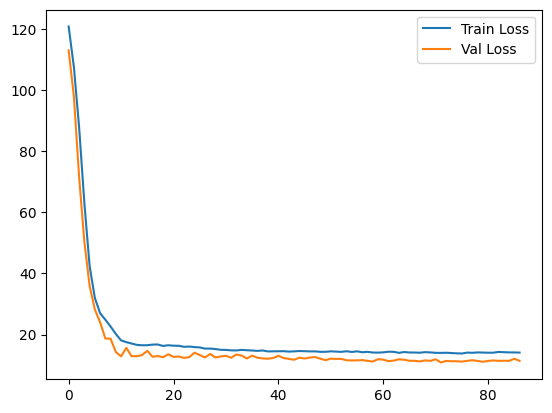

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights
import numpy as np
import time
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2

# Select device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define WingLoss: a robust loss for keypoint regression
class WingLoss(nn.Module):
    def __init__(self, omega=10, epsilon=2):
        super(WingLoss, self).__init__()
        self.omega = omega
        self.epsilon = epsilon
        # Constant term to ensure continuity at diff == omega
        self.C = self.omega - self.omega * np.log(1 + self.omega / self.epsilon)

    def forward(self, pred, target):
        diff = torch.abs(pred - target)
        condition = diff < self.omega
        loss = torch.where(
            condition,
            self.omega * torch.log(1 + diff / self.epsilon),
            diff - self.C
        )
        return loss.mean()

# Preprocess images and optionally scale landmarks
def preprocess_data(images, landmarks=None, target_size=(224, 224)):
    print("Preprocessing images and landmarks...")
    processed_images = []
    processed_landmarks = []
    for i, img in enumerate(images):
        orig_h, orig_w = img.shape[:2]
        # Resize image
        resized = cv2.resize(img, target_size)
        # Normalize pixel values to [0,1]
        normalized = resized.astype(np.float32) / 255.0
        processed_images.append(normalized)
        if landmarks is not None:
            sx = target_size[0] / orig_w
            sy = target_size[1] / orig_h
            pts = landmarks[i].copy()
            pts[:, 0] *= sx
            pts[:, 1] *= sy
            processed_landmarks.append(pts)
    imgs_np = np.array(processed_images)
    if landmarks is not None:
        return imgs_np, np.array(processed_landmarks)
    else:
        return imgs_np, None

# Data augmentation: random rotation, horizontal flip, brightness & contrast change
class FaceAlignmentTransform:
    def __init__(self, rotation_range=10, flip_prob=0.5, brightness=0.2, contrast=0.2):
        self.rotation_range = rotation_range
        self.flip_prob = flip_prob
        self.brightness = brightness
        self.contrast = contrast

    def __call__(self, image, landmarks):
        # Convert tensor to H×W×C numpy if needed
        if isinstance(image, torch.Tensor):
            img_np = image.numpy().transpose(1,2,0)
        else:
            img_np = image.copy()
        pts = landmarks.clone().numpy() if isinstance(landmarks, torch.Tensor) else landmarks.copy()
        h, w = img_np.shape[:2]
        center = (w/2, h/2)

        # Random rotation
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-self.rotation_range, self.rotation_range)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img_np = cv2.warpAffine(img_np, M, (w,h), borderMode=cv2.BORDER_REFLECT)
            pts_h = np.hstack([pts, np.ones((pts.shape[0],1))])
            pts = np.dot(pts_h, M.T)

        # Random horizontal flip
        if np.random.rand() < self.flip_prob:
            img_np = cv2.flip(img_np, 1)
            pts[:,0] = w - pts[:,0]

        # Random brightness & contrast
        alpha = np.random.uniform(1-self.contrast, 1+self.contrast)
        beta = np.random.uniform(-self.brightness, self.brightness)
        img_np = np.clip(alpha * img_np + beta, 0, 1)

        # Convert back to tensor C×H×W if needed
        if isinstance(image, torch.Tensor):
            img_np = img_np.transpose(2,0,1)
            return torch.from_numpy(img_np.astype(np.float32)), torch.from_numpy(pts.astype(np.float32))
        return img_np, pts

# Dataset wrapper for face alignment
class FaceAlignmentDataset(Dataset):
    def __init__(self, images, landmarks, transform=None):
        self.images = images
        self.landmarks = landmarks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        pts = self.landmarks[idx]
        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img]*3, axis=2)
        # Convert to tensor format C×H×W
        img = img.transpose((2,0,1)).astype(np.float32)
        pts = pts.astype(np.float32)
        if self.transform:
            img, pts = self.transform(img, pts)
        return torch.tensor(img), torch.tensor(pts)

# Face keypoint regression model using a frozen ResNet backbone
# Face keypoint regression model using a frozen ResNet backbone
class FaceKeypointResNet(nn.Module):
    def __init__(self, num_keypoints, backbone='resnet18', pretrained=True):
        super().__init__()
        if backbone == 'resnet18':
            base = models.resnet18(pretrained=pretrained)
        elif backbone == 'resnet34':
            base = models.resnet34(pretrained=pretrained)
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")
        # Remove final pooling & FC layers
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.regressor = nn.Sequential(
            nn.Linear(base.fc.in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_keypoints * 2)
        )
        # Selective freezing of the backbone network
        for name, param in self.backbone.named_parameters():
            if 'layer1' in name or 'layer2' in name or 'conv1' in name or 'bn1' in name:
                param.requires_grad = False
            else:  # layer3, layer4, etc. remain trainable
                param.requires_grad = True

    def forward(self, x):
        f = self.backbone(x)
        p = self.avg_pool(f).view(f.size(0), -1)
        k = self.regressor(p)
        return k.view(-1, k.size(1)//2, 2)

# Training loop with early stopping and LR scheduling
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, num_epochs=200, patience=10):
    print("Starting training...")
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        model.train()
        running_train = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_train += loss.item() * x.size(0)
        epoch_train = running_train / len(train_loader.dataset)
        history['train_loss'].append(epoch_train)
        print(f"  Train Loss: {epoch_train:.4f}")

        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                running_val += criterion(out, y).item() * x.size(0)
        epoch_val = running_val / len(val_loader.dataset)
        history['val_loss'].append(epoch_val)
        print(f"  Val Loss:   {epoch_val:.4f}")

        scheduler.step(epoch_val)
        if epoch_val < best_loss:
            best_loss = epoch_val
            best_wts = copy.deepcopy(model.state_dict())
            counter = 0
            print("  Validation loss decreased; saving best weights.")
        else:
            counter += 1
            print(f"  No improvement; early stopping counter: {counter}/{patience}")
            if counter >= patience:
                print("  Early stopping triggered.")
                break

    model.load_state_dict(best_wts)
    print("Training complete.")
    return model, history

def main():
    # 1. Load training data
    print("1. Loading training data...")
    data = np.load('face_alignment_training_images.npz')
    imgs, pts = data['images'], data['points']
    print(f"  Images shape: {imgs.shape}, Landmarks shape: {pts.shape}")

    # 2. Preprocess images and landmarks
    print("2. Preprocessing images and landmarks...")
    imgs, pts = preprocess_data(imgs, pts)
    print(f"  Preprocessed images shape: {imgs.shape}, Landmarks shape: {pts.shape}")

    # 3. Split into train/validation sets
    print("3. Splitting train and validation sets...")
    X_tr, X_val, y_tr, y_val = train_test_split(imgs, pts, test_size=0.2, random_state=42)
    print(f"  Train set: {X_tr.shape}, Validation set: {X_val.shape}")

    # 4. Create Dataset and DataLoader
    print("4. Creating Dataset and DataLoader...")
    transform = FaceAlignmentTransform()
    train_ds = FaceAlignmentDataset(X_tr, y_tr, transform=transform)
    val_ds = FaceAlignmentDataset(X_val, y_val)
    train_ld = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=32)
    print("  DataLoaders ready.")

    # 5. Initialize model, loss, optimizer, scheduler
    print("5. Initializing model, loss function, optimizer, scheduler...")
    model = FaceKeypointResNet(pts.shape[1], backbone='resnet18').to(device)
    criterion = WingLoss()
    optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'backbone' in n and p.requires_grad], 'lr': 1e-4},
    {'params': [p for n, p in model.named_parameters() if 'backbone' not in n], 'lr': 1e-3}
], weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
    print("  Initialization done.")

    # 6. Train the model
    print("6. Beginning training loop...")
    model, history = train_model(
        model, train_ld, val_ld, criterion, optimizer, scheduler,
        device, num_epochs=200, patience=15
    )

    # 7. Save model and plot loss curves
    print("7. Saving model and plotting loss curves...")
    torch.save(model.state_dict(), 'face_keypoint_resnet18.pth')
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.savefig('training_history.png')
    print("  Model and loss curves saved.")

    return pts, val_ld,history
   # Save history after training
pts, val_loader, history = main()
torch.save(history, 'resnet18_history.pth')
   # Load where you need to draw
history_resnet18 = torch.load('resnet18_history.pth')
if __name__ == "__main__":
    pts, val_loader = main()

# Load best model and evaluate (example)
model = FaceKeypointResNet(pts.shape[1], backbone='resnet18').to(device)
model.load_state_dict(torch.load('face_keypoint_resnet18.pth', weights_only=True))
model.eval()
print("8. Loaded best model for evaluation and visualization.")


Loading and evaluating ResNet18 model...


E:\TEMP\ipykernel_18476\3930443875.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet18.load_state_dict(torch.load('face_keypoint_resnet18.pth'))


Validation average loss (MSE): 43.9984
Mean Squared Error (MSE): 43.9984
Mean Absolute Error (MAE): 4.9157
Mean Euclidean distance error: 7.6928 pixels
Minimum image error: 1.6793, Maximum image error: 32.0389


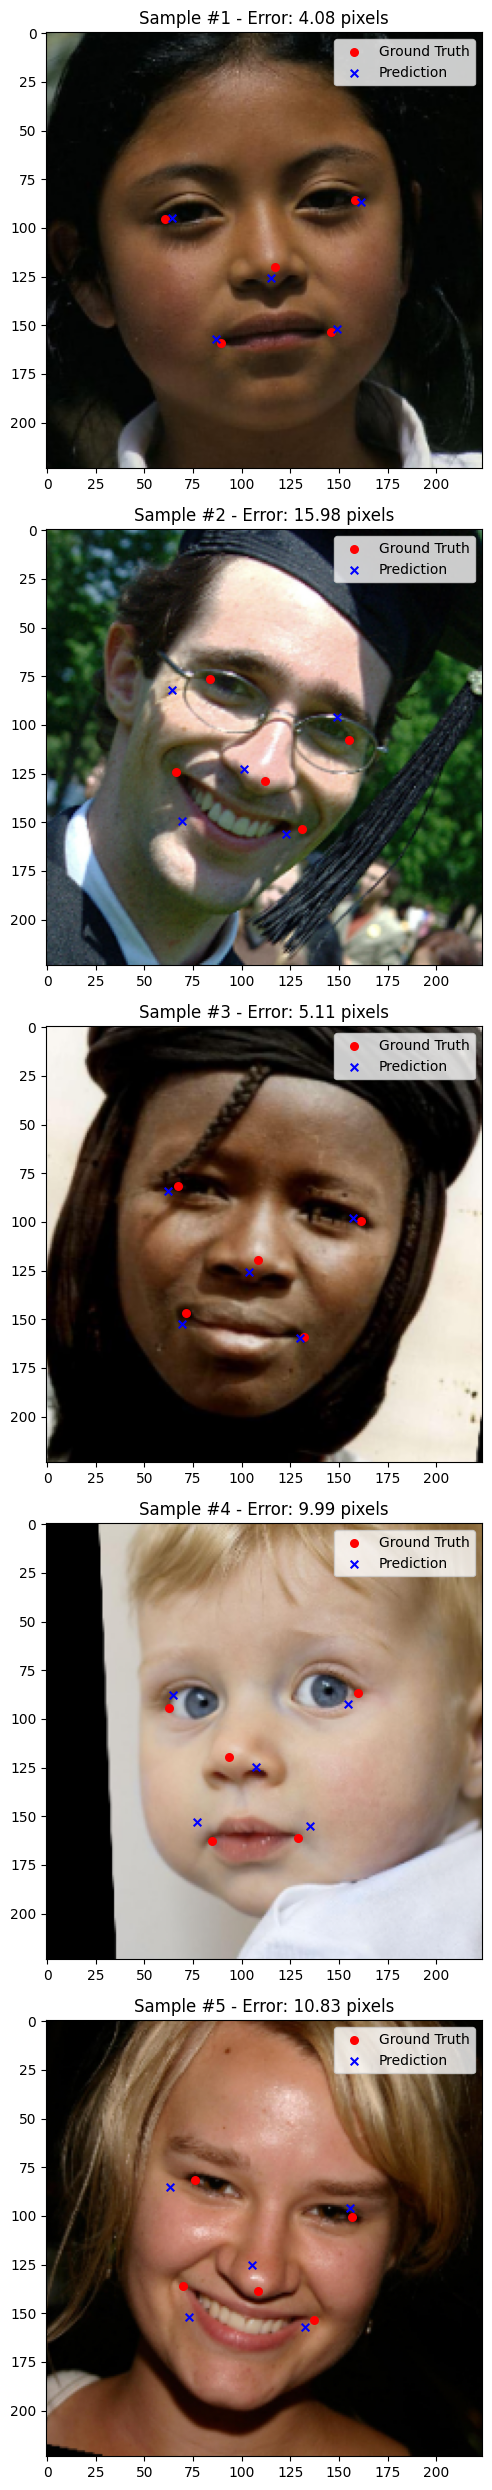

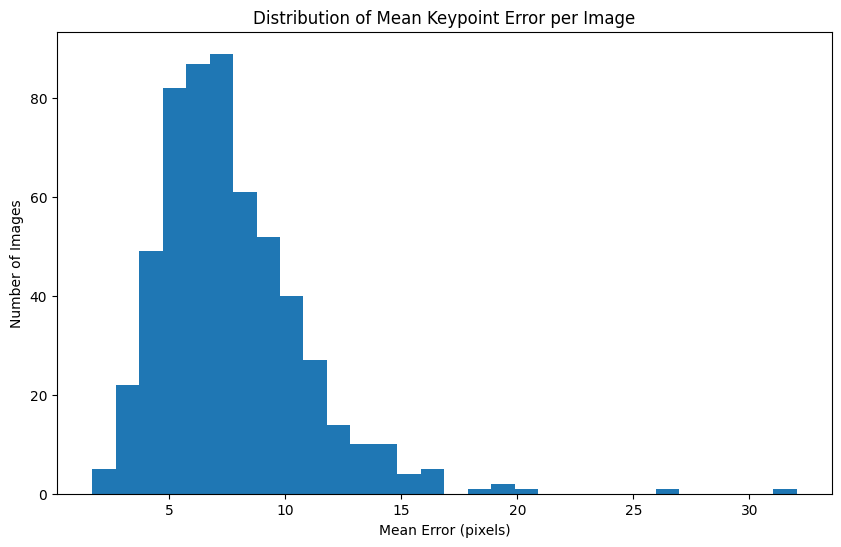

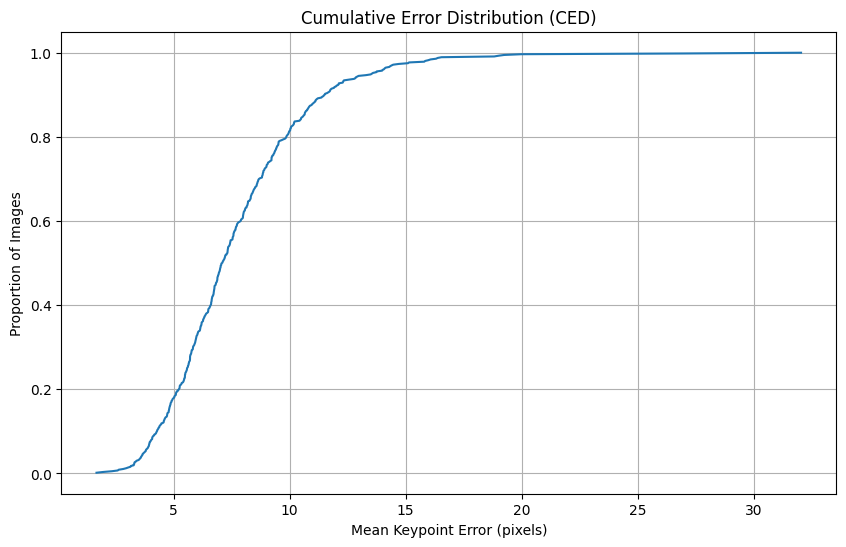


Loading and evaluating ResNet34 model...


E:\TEMP\ipykernel_18476\3930443875.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet34.load_state_dict(torch.load('face_keypoint_resnet34.pth'))


Validation average loss (MSE): 27.4875
Mean Squared Error (MSE): 27.4875
Mean Absolute Error (MAE): 3.9083
Mean Euclidean distance error: 6.1646 pixels
Minimum image error: 1.9930, Maximum image error: 29.2254


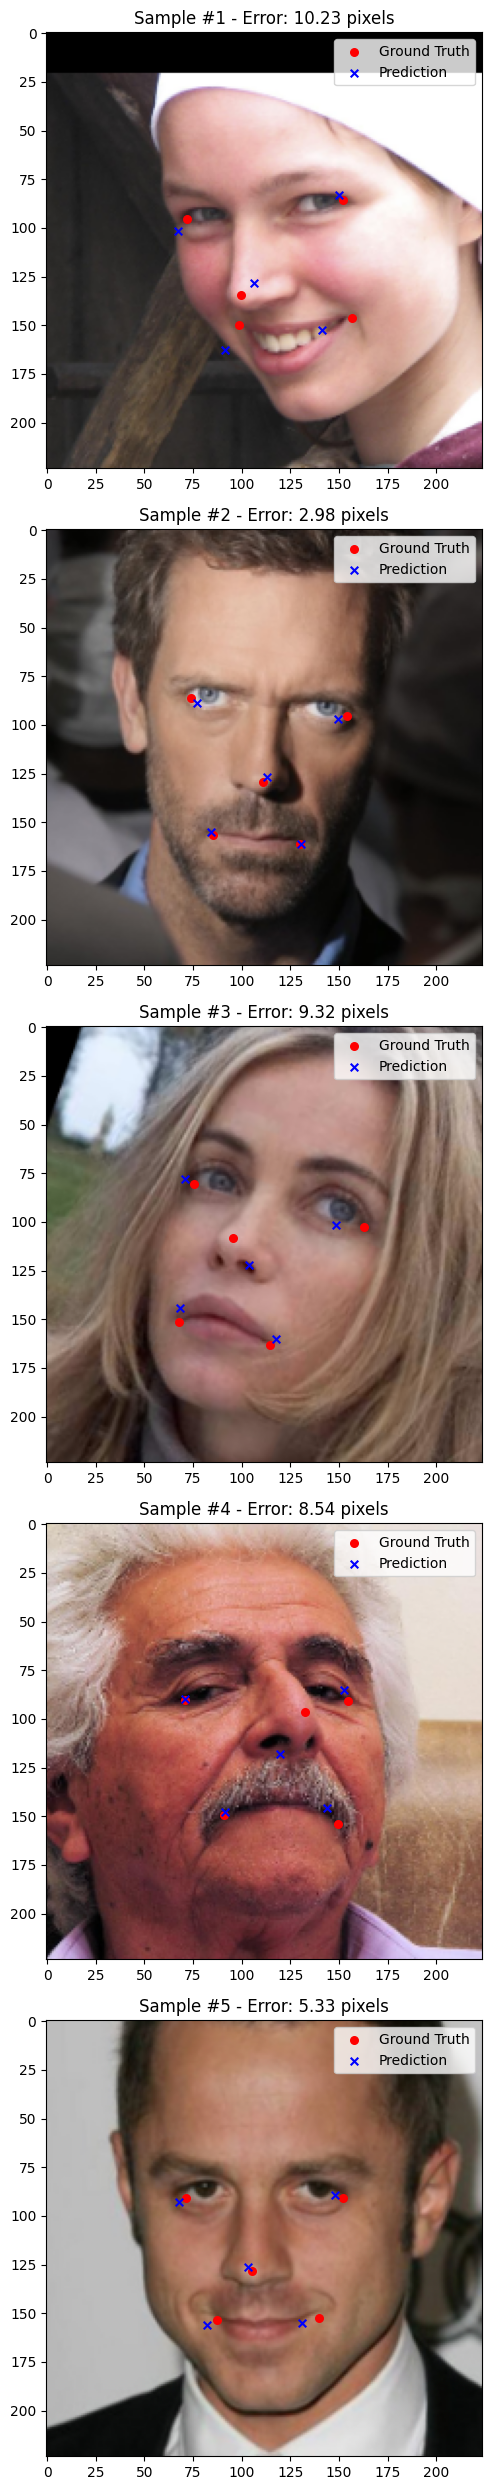

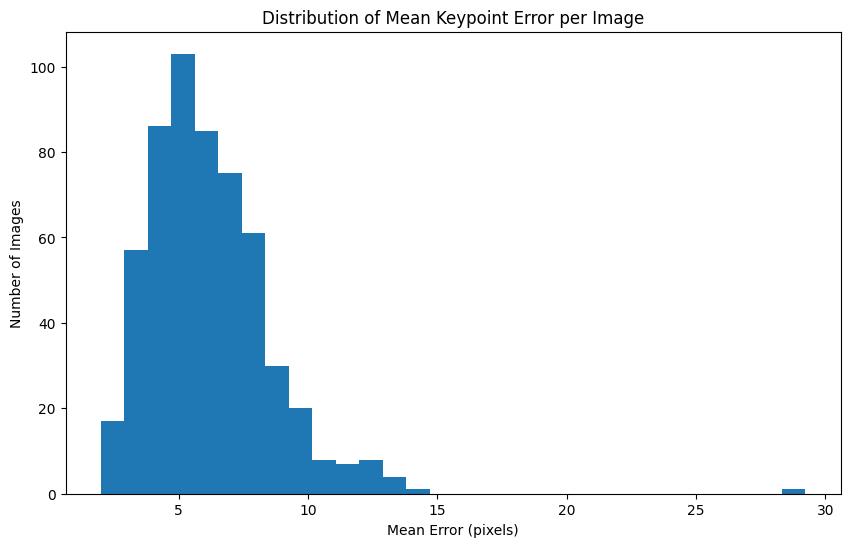

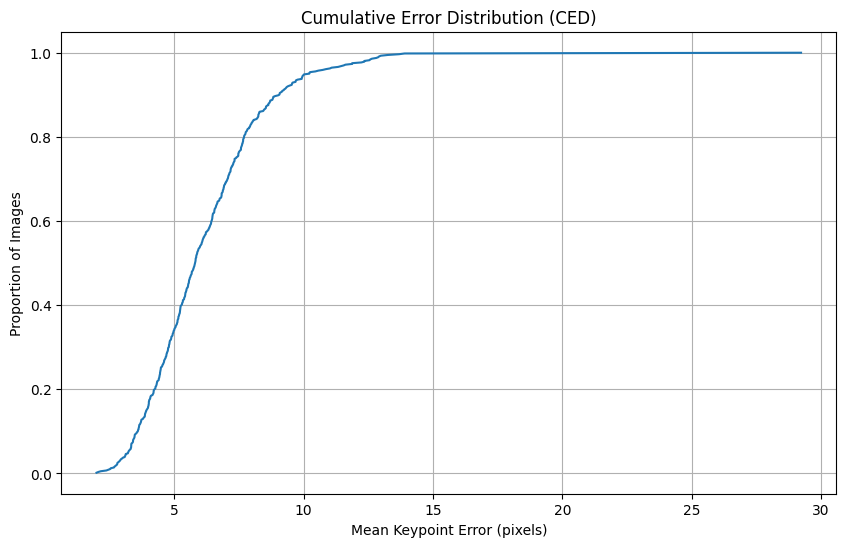


Model Comparison Results:
------------------------------------------------------------
Metric              ResNet18       ResNet34       Improvement (%)
------------------------------------------------------------
Avg Loss            43.9984        27.4875        37.53          
Euclidean Error     7.6928         6.1646         19.87          
MSE                 43.9984        27.4875        37.53          
MAE                 4.9157         3.9083         20.49          
------------------------------------------------------------
Error during model evaluation: Given groups=1, weight of size [64, 3, 7, 7], expected input[563, 224, 224, 3] to have 3 channels, but got 224 channels instead
Make sure both ResNet18 and ResNet34 models have been trained and saved.


<Figure size 1200x600 with 0 Axes>

In [32]:
# New cell: Model comparison and visualization evaluation

# 1. Update evaluation function to include MSE and MAE metrics
def evaluate_and_visualize_with_metrics(model, val_loader, device, model_name="model", num_samples=5):
    """
    Evaluate model performance and visualize predictions, including MSE and MAE metrics.

    Args:
        model: trained model
        val_loader: DataLoader for the validation set
        device: torch.device ('cpu' or 'cuda')
        model_name: name of the model (used for saving figures)
        num_samples: number of samples to visualize
    """
    model.eval()
    
    all_predictions = []
    all_targets = []
    
    # Randomly select samples for visualization
    random_indices = np.random.choice(len(val_loader.dataset), num_samples, replace=False)
    images_to_show = []
    true_keypoints = []
    pred_keypoints = []
    
    total_loss = 0.0
    criterion = torch.nn.MSELoss()
    sample_count = 0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            
            loss = criterion(outputs, targets)
            total_loss += loss.item() * images.size(0)
            
            all_predictions.extend(outputs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            for i in range(images.size(0)):
                if sample_count in random_indices:
                    img = images[i].cpu().numpy().transpose(1, 2, 0)  # CHW -> HWC
                    img = np.clip(img * 255, 0, 255).astype(np.uint8)
                    images_to_show.append(img)
                    true_keypoints.append(targets[i].cpu().numpy())
                    pred_keypoints.append(outputs[i].cpu().numpy())
                sample_count += 1
    
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    avg_loss = total_loss / len(val_loader.dataset)
    print(f"Validation average loss (MSE): {avg_loss:.4f}")
    
    # Compute MSE and MAE
    mse = np.mean((all_predictions - all_targets) ** 2)
    mae = np.mean(np.abs(all_predictions - all_targets))
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    
    # Euclidean distance per keypoint
    euclidean_dist = np.sqrt(np.sum((all_predictions - all_targets) ** 2, axis=2))
    mean_error = np.mean(euclidean_dist)
    per_image_error = np.mean(euclidean_dist, axis=1)
    
    print(f"Mean Euclidean distance error: {mean_error:.4f} pixels")
    print(f"Minimum image error: {np.min(per_image_error):.4f}, Maximum image error: {np.max(per_image_error):.4f}")
    
    # Visualization of a few samples
    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(min(num_samples, len(images_to_show))):
        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(images_to_show[i])
        plt.scatter(true_keypoints[i][:, 0], true_keypoints[i][:, 1], c='r', marker='o', s=30, label='Ground Truth')
        plt.scatter(pred_keypoints[i][:, 0], pred_keypoints[i][:, 1], c='b', marker='x', s=30, label='Prediction')
        sample_err = np.mean(np.linalg.norm(true_keypoints[i] - pred_keypoints[i], axis=1))
        plt.title(f'Sample #{i+1} - Error: {sample_err:.2f} pixels')
        plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name}_visualization.png')
    plt.show()
    
    # Error histogram
    plt.figure(figsize=(10, 6))
    plt.hist(per_image_error, bins=30)
    plt.title('Distribution of Mean Keypoint Error per Image')
    plt.xlabel('Mean Error (pixels)')
    plt.ylabel('Number of Images')
    plt.savefig(f'{model_name}_error_histogram.png')
    plt.show()
    
    # Cumulative Error Distribution (CED)
    sorted_errors = np.sort(per_image_error)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_errors, cumulative)
    plt.grid(True)
    plt.title('Cumulative Error Distribution (CED)')
    plt.xlabel('Mean Keypoint Error (pixels)')
    plt.ylabel('Proportion of Images')
    plt.savefig(f'{model_name}_ced_curve.png')
    plt.show()
    
    return avg_loss, mean_error, mse, mae, all_predictions, all_targets

# 2. Load and evaluate both models
try:
    # ResNet18
    print("Loading and evaluating ResNet18 model...")
    model_resnet18 = FaceKeypointResNet(pts.shape[1], backbone='resnet18').to(device)
    model_resnet18.load_state_dict(torch.load('face_keypoint_resnet18.pth'))
    model_resnet18.eval()
    
    avg_loss18, mean_error18, mse18, mae18, _, _ = evaluate_and_visualize_with_metrics(
        model_resnet18, val_loader, device, model_name="ResNet18"
    )
    
    # ResNet34
    print("\nLoading and evaluating ResNet34 model...")
    model_resnet34 = FaceKeypointResNet34(pts.shape[1]).to(device)
    model_resnet34.load_state_dict(torch.load('face_keypoint_resnet34.pth'))
    model_resnet34.eval()
    
    avg_loss34, mean_error34, mse34, mae34, _, _ = evaluate_and_visualize_with_metrics(
        model_resnet34, val_loader, device, model_name="ResNet34"
    )
    
    # 3. Print comparison results
    print("\nModel Comparison Results:")
    print("-" * 60)
    print(f"{'Metric':<20}{'ResNet18':<15}{'ResNet34':<15}{'Improvement (%)':<15}")
    print("-" * 60)
    print(f"{'Avg Loss':<20}{avg_loss18:<15.4f}{avg_loss34:<15.4f}{(avg_loss18-avg_loss34)/avg_loss18*100:<15.2f}")
    print(f"{'Euclidean Error':<20}{mean_error18:<15.4f}{mean_error34:<15.4f}{(mean_error18-mean_error34)/mean_error18*100:<15.2f}")
    print(f"{'MSE':<20}{mse18:<15.4f}{mse34:<15.4f}{(mse18-mse34)/mse18*100:<15.2f}")
    print(f"{'MAE':<20}{mae18:<15.4f}{mae34:<15.4f}{(mae18-mae34)/mae18*100:<15.2f}")
    print("-" * 60)
    
    # 4. Plot CED comparison curve
    plt.figure(figsize=(12, 6))
    
    euclid18 = np.sqrt(np.sum(
        (model_resnet18(torch.tensor(X_val).to(device)).cpu().detach().numpy() - y_val) ** 2, axis=2))
    euclid34 = np.sqrt(np.sum(
        (model_resnet34(torch.tensor(X_val).to(device)).cpu().detach().numpy() - y_val) ** 2, axis=2))
    
    err18 = np.mean(euclid18, axis=1)
    err34 = np.mean(euclid34, axis=1)
    
    sorted18 = np.sort(err18)
    sorted34 = np.sort(err34)
    cumulative = np.arange(1, len(sorted18) + 1) / len(sorted18)
    
    plt.plot(sorted18, cumulative, 'r-', label='ResNet18')
    plt.plot(sorted34, cumulative, 'b-', label='ResNet34')
    plt.grid(True)
    plt.title('CED Comparison: ResNet18 vs ResNet34')
    plt.xlabel('Mean Keypoint Error (pixels)')
    plt.ylabel('Proportion of Images')
    plt.legend()
    plt.savefig('model_ced_comparison.png')
    plt.show()
    
    # 5. If training histories are available, plot loss curves comparison
    try:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_resnet18['train_loss'], 'r-', label='ResNet18')
        plt.plot(history_resnet34['train_loss'], 'b-', label='ResNet34')
        plt.title('Training Loss Comparison')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history_resnet18['val_loss'], 'r-', label='ResNet18')
        plt.plot(history_resnet34['val_loss'], 'b-', label='ResNet34')
        plt.title('Validation Loss Comparison')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig('model_loss_comparison.png')
        plt.show()
    except Exception as e:
        print(f"Could not plot loss curves: {e}")
        print("Ensure training histories are saved and loaded as history_resnet18 and history_resnet34.")

except Exception as e:
    print(f"Error during model evaluation: {e}")
    print("Make sure both ResNet18 and ResNet34 models have been trained and saved.")

In [33]:
# Failure case analysis code

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

def analyze_failure_cases(model, val_loader, device, threshold=20.0, num_cases=5):
    """
    Analyze model failure cases, find samples with largest errors
    
    Parameters:
        model: trained model
        val_loader: validation data loader
        device: device (CPU/GPU)
        threshold: error threshold to identify failure cases
        num_cases: number of failure samples to visualize for each category
    Returns:
        failure_cases: dictionary of failure cases, classified by type
    """
    model.eval()
    failure_cases = {
        'extreme_pose': [], # Extreme poses
        'low_light': [],    # Low lighting conditions
        'occlusion': [],    # Facial occlusion
        'others': []        # Other failure cases
    }
    
    all_errors = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            
            # Calculate Euclidean distance error for each sample
            pred_np = outputs.cpu().numpy()
            target_np = targets.cpu().numpy()
            
            for i in range(images.size(0)):
                # Calculate Euclidean distance error for each keypoint
                distances = np.sqrt(np.sum((pred_np[i] - target_np[i])**2, axis=1))
                mean_error = np.mean(distances)
                all_errors.append(mean_error)
                
                # Identify failure cases
                if mean_error > threshold:
                    img = images[i].cpu().numpy().transpose(1, 2, 0)
                    img = np.clip(img * 255, 0, 255).astype(np.uint8)
                    
                    # Classify failure cases (using simple heuristic rules)
                    # In production, more complex methods should be used
                    face_area = img.shape[0] * img.shape[1]
                    face_brightness = np.mean(img)
                    keypoint_spread = np.max(distances) - np.min(distances)
                    
                    case = {
                        'image': img,
                        'true_points': target_np[i],
                        'pred_points': pred_np[i],
                        'error': mean_error
                    }
                    
                    # Simple classification criteria (more complex criteria should be used in practice)
                    if keypoint_spread > 15.0:  # Uneven distribution of keypoint predictions
                        failure_cases['extreme_pose'].append(case)
                    elif face_brightness < 0.3:  # Low brightness
                        failure_cases['low_light'].append(case)
                    elif np.std(distances) > 10.0:  # Some keypoints with large errors, some small
                        failure_cases['occlusion'].append(case)
                    else:
                        failure_cases['others'].append(case)
    
    # Plot error distribution histogram
    plt.figure(figsize=(10, 6))
    plt.hist(all_errors, bins=30, alpha=0.7, color='blue')
    plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Failure Threshold ({threshold})')
    plt.title('Distribution of Keypoint Detection Errors')
    plt.xlabel('Mean Euclidean Error (pixels)')
    plt.ylabel('Number of Samples')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Visualize several examples for each failure case type
    for failure_type, cases in failure_cases.items():
        if len(cases) == 0:
            continue
            
        # Sort by error, select the most severe cases
        sorted_cases = sorted(cases, key=lambda x: x['error'], reverse=True)
        num_to_show = min(num_cases, len(sorted_cases))
        
        plt.figure(figsize=(15, 4 * num_to_show))
        for i in range(num_to_show):
            case = sorted_cases[i]
            plt.subplot(num_to_show, 1, i + 1)
            plt.imshow(case['image'])
            
            # Plot true keypoints (red circles)
            plt.scatter(case['true_points'][:, 0], case['true_points'][:, 1], 
                      c='r', marker='o', s=30, label='True Keypoints')
            
            # Plot predicted keypoints (blue x's)
            plt.scatter(case['pred_points'][:, 0], case['pred_points'][:, 1], 
                      c='b', marker='x', s=30, label='Predicted Keypoints')
            
            plt.title(f"{failure_type.replace('_', ' ').title()}: Error = {case['error']:.2f} pixels")
            plt.legend()
        
        plt.tight_layout()
        plt.savefig(f'{failure_type}_failures.png', dpi=300, bbox_inches='tight')
        plt.close()
        
    return failure_cases, all_errors

def calculate_error_statistics(all_errors):
    """Calculate error statistics"""
    percentiles = [50, 75, 90, 95, 99]
    percentile_values = np.percentile(all_errors, percentiles)
    
    stats = {
        'mean': np.mean(all_errors),
        'median': np.median(all_errors),
        'std': np.std(all_errors),
        'max': np.max(all_errors),
        'min': np.min(all_errors),
        'percentiles': {p: v for p, v in zip(percentiles, percentile_values)}
    }
    
    return stats

def plot_ced_curve(errors, model_name, color='blue'):
    """Plot Cumulative Error Distribution curve"""
    errors = np.sort(errors)
    y = np.arange(1, len(errors) + 1) / len(errors)
    
    return errors, y, model_name, color

# Example usage
if __name__ == "__main__":
    # Load model and validation data
    model_resnet18 = FaceKeypointResNet(5).to(device)  # Assuming 5 keypoints
    model_resnet18.load_state_dict(torch.load('face_keypoint_resnet18.pth'))
    
    model_resnet34 = FaceKeypointResNet34(5).to(device)
    model_resnet34.load_state_dict(torch.load('face_keypoint_resnet34.pth'))
    
    # Analyze failure cases for both models
    failure_cases_18, errors_18 = analyze_failure_cases(model_resnet18, val_loader, device)
    failure_cases_34, errors_34 = analyze_failure_cases(model_resnet34, val_loader, device)
    
    # Calculate statistics
    stats_18 = calculate_error_statistics(errors_18)
    stats_34 = calculate_error_statistics(errors_34)
    
    print("ResNet18 Error Statistics:")
    print(f"Mean Error: {stats_18['mean']:.4f} pixels")
    print(f"Median Error: {stats_18['median']:.4f} pixels")
    print(f"Maximum Error: {stats_18['max']:.4f} pixels")
    print(f"Standard Deviation: {stats_18['std']:.4f} pixels")
    print("Percentiles:")
    for p, v in stats_18['percentiles'].items():
        print(f"  {p}%: {v:.4f} pixels")
    
    print("\nResNet34 Error Statistics:")
    print(f"Mean Error: {stats_34['mean']:.4f} pixels")
    print(f"Median Error: {stats_34['median']:.4f} pixels")
    print(f"Maximum Error: {stats_34['max']:.4f} pixels")
    print(f"Standard Deviation: {stats_34['std']:.4f} pixels")
    print("Percentiles:")
    for p, v in stats_34['percentiles'].items():
        print(f"  {p}%: {v:.4f} pixels")
    
    # Plot CED curve comparison for both models
    plt.figure(figsize=(10, 6))
    
    data_18 = plot_ced_curve(errors_18, 'ResNet18', 'blue')
    data_34 = plot_ced_curve(errors_34, 'ResNet34', 'red')
    
    for errors, y, name, color in [data_18, data_34]:
        plt.plot(errors, y, color=color, label=name)
    
    plt.grid(True, alpha=0.3)
    plt.xlabel('Normalized Point-to-Point Error')
    plt.ylabel('Images Proportion')
    plt.title('Cumulative Error Distribution')
    plt.legend()
    plt.savefig('ced_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

E:\TEMP\ipykernel_18476\2884851725.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet18.load_state_dict(torch.load('face_keypoint_resnet18.pth'))
E:\TEMP\ipy

ResNet18 Error Statistics:
Mean Error: 7.6928 pixels
Median Error: 7.1054 pixels
Maximum Error: 32.0389 pixels
Standard Deviation: 3.2005 pixels
Percentiles:
  50%: 7.1054 pixels
  75%: 9.2239 pixels
  90%: 11.5079 pixels
  95%: 13.5443 pixels
  99%: 17.4071 pixels

ResNet34 Error Statistics:
Mean Error: 6.1646 pixels
Median Error: 5.8019 pixels
Maximum Error: 29.2254 pixels
Standard Deviation: 2.3961 pixels
Percentiles:
  50%: 5.8019 pixels
  75%: 7.3931 pixels
  90%: 9.0555 pixels
  95%: 10.1982 pixels
  99%: 12.8935 pixels


# Calculating Prediction Error and exporting results

In [41]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [3]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')


e:\AML task 2


In [48]:
np.save('landmarks.npy', pts) 
np.savetxt('landmarks.csv', pts.reshape(pts.shape[0], -1), delimiter=',')  